In [7]:
import matplotlib.pyplot as plt
import scipy.signal as sig
import numpy as np
import os

#from baseband_analysis.core.dedispersion import incoherent_dedisp, coherent_dedisp, get_freq

from matplotlib import rcParams

rcParams['font.family'] = 'serif'
rcParams['font.serif'] = ['cmr10']
rcParams['font.size'] = 32
rcParams['axes.formatter.use_mathtext'] = True
rcParams['axes.unicode_minus'] = False
rcParams['mathtext.fontset'] = 'cm'

In [8]:
os.listdir('chime_npy')

['I_224263996_oran.npy',
 'I_252069198_isha.npy',
 'I_215063905_whitney.npy',
 'I_356959136_chromatica.npy',
 'I_318353610_hamilton.npy',
 'I_210456524_zach.npy',
 'I_311723353_johndoeII.npy',
 'I_274819243_phineas.npy',
 'I_278720455_freya.npy',
 'I_354049284_mahi.npy',
 'I_362593221_casey.npy',
 'I_253635173_wilhelm.npy']

In [9]:
os.listdir('dsa_npy')

['I_220506aabd_oran.npy',
 'I_240229aaad_casey.npy',
 'I_240203aacl_chromatica.npy',
 'I_230814aaas_johndoeII.npy',
 'I_230712aadj_pingu.npy',
 'I_230307aaao_phineas.npy',
 'I_220310aaam_whitney.npy',
 'I_354049284_mahi.npy',
 'I_230325aaag_freya.npy',
 'I_221203aaaa_wilhelm.npy',
 'I_230913aaao_hamilton.npy',
 'I_220207aabh_zach.npy']

In [10]:
dsa_tres = 32.5e-3 #ms
chime_tres = 2.56e-3 #ms

${\huge \mathbf{Zach}}$

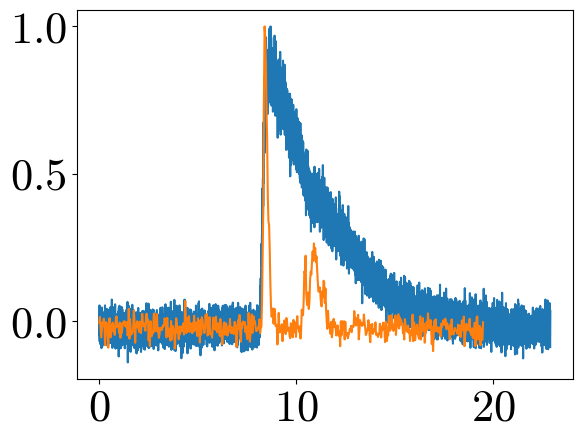

In [11]:
zach_dsa = np.load('dsa_npy/I_220207aabh_zach.npy')
dsa_burst = zach_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
zach_chime = np.load('chime_npy/I_210456524_zach.npy')
chime_burst = zach_chime
chime_burst = np.roll(chime_burst[:, 20650:29600], 290)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No handles with labels found to put in legend.


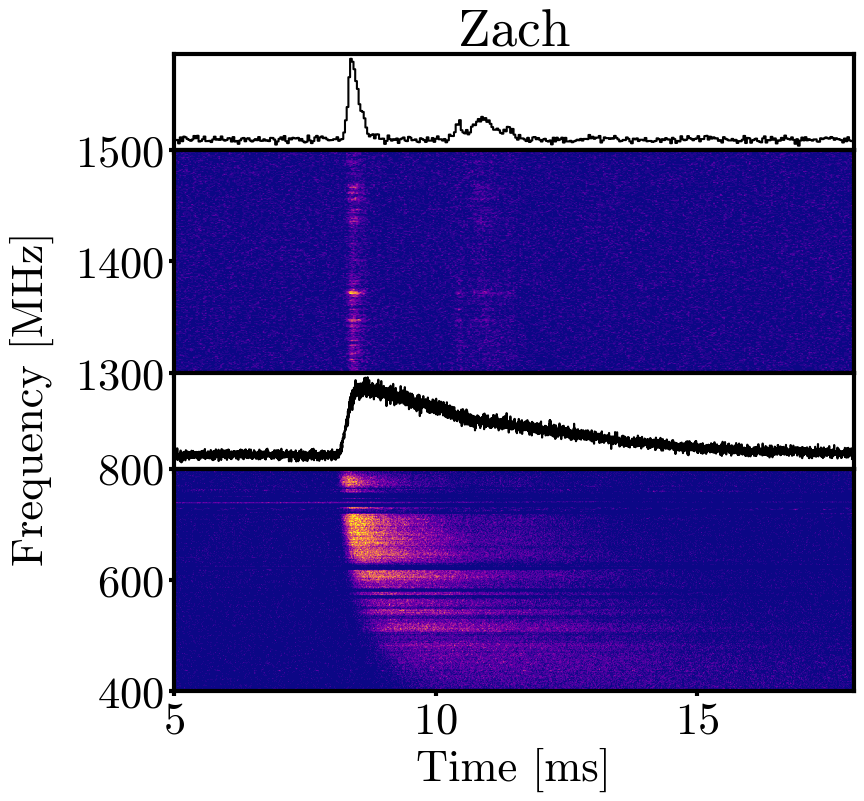

In [12]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Zach')
plt.xlim(5, 18)
plt.show()

fig.savefig('DSA_CHIME_Zach_wfall.pdf', bbox_inches = 'tight')

${\huge \huge \mathbf{Wilhelm}}$

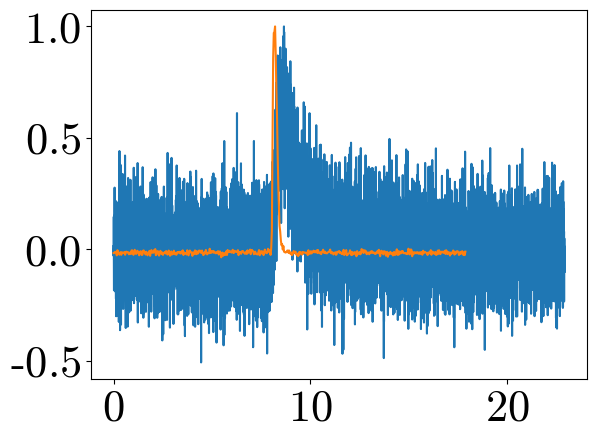

In [13]:
wilhelm_dsa = np.load('dsa_npy/I_221203aaaa_wilhelm.npy')
dsa_burst = wilhelm_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
wilhelm_chime = np.load('chime_npy/I_253635173_wilhelm.npy')
chime_burst = wilhelm_chime
chime_burst = np.roll(chime_burst[:, 20650:29600], -2900)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No handles with labels found to put in legend.


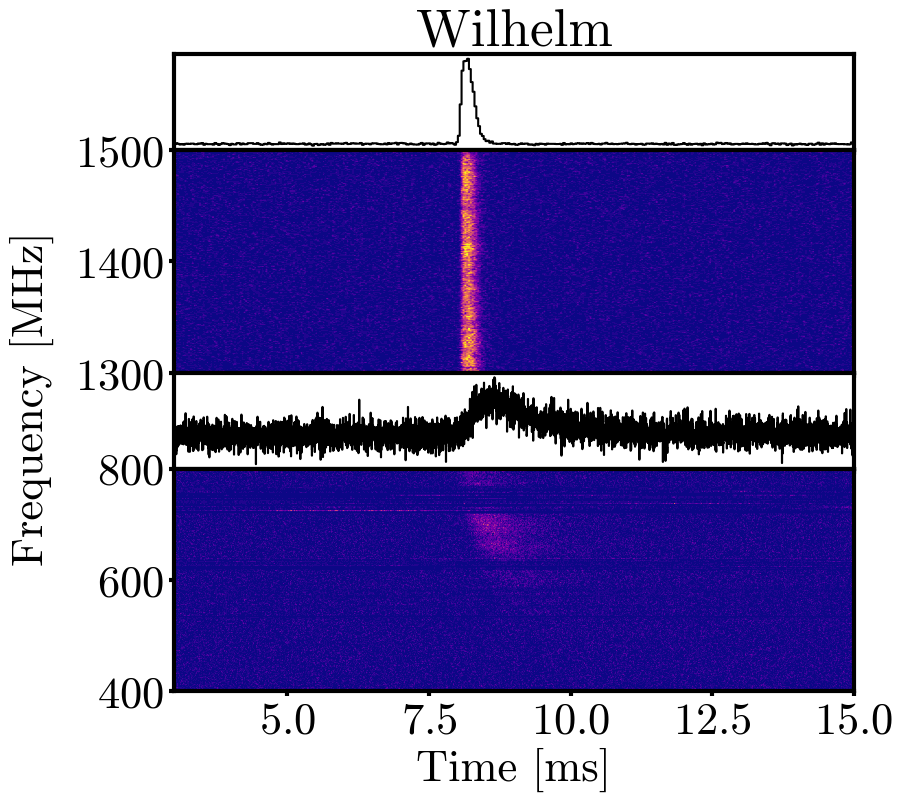

In [14]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Wilhelm')
plt.xlim(3, 15)
plt.show()

fig.savefig('DSA_CHIME_Wilhelm_wfall.pdf', bbox_inches = 'tight')

${\huge \huge \mathbf{Chromatica}}$

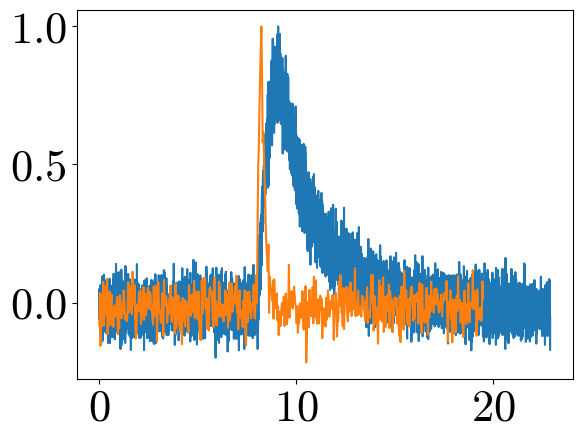

In [15]:
chromatica_dsa = np.load('dsa_npy/I_240203aacl_chromatica.npy')
dsa_burst = chromatica_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
chromatica_chime = np.load('chime_npy/I_356959136_chromatica.npy')
chime_burst = chromatica_chime
chime_burst = np.roll(chime_burst[:, 20650:29600], 2100)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No handles with labels found to put in legend.


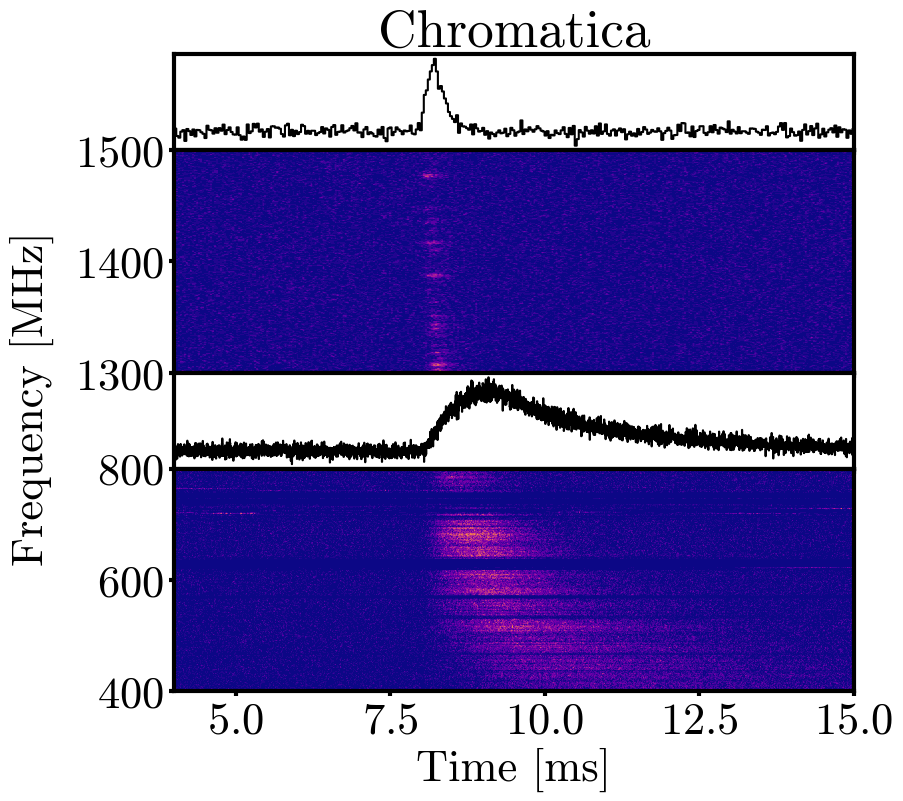

In [16]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Chromatica')
plt.xlim(4, 15)
plt.show()
fig.savefig('DSA_CHIME_Chromatica_wfall.pdf', bbox_inches = 'tight')

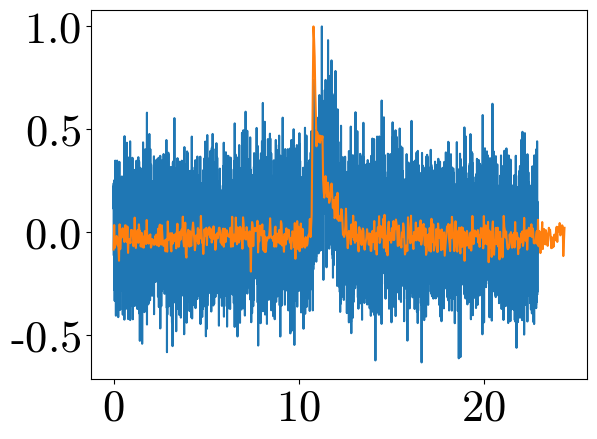

In [17]:
johndoe_dsa = np.load('dsa_npy/I_230814aaas_johndoeII.npy')
dsa_burst = johndoe_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
johndoe_chime = np.load('chime_npy/I_311723353_johndoeII.npy')
chime_burst = johndoe_chime
chime_burst = np.roll(chime_burst[:, 20650:29600], -4200)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No handles with labels found to put in legend.


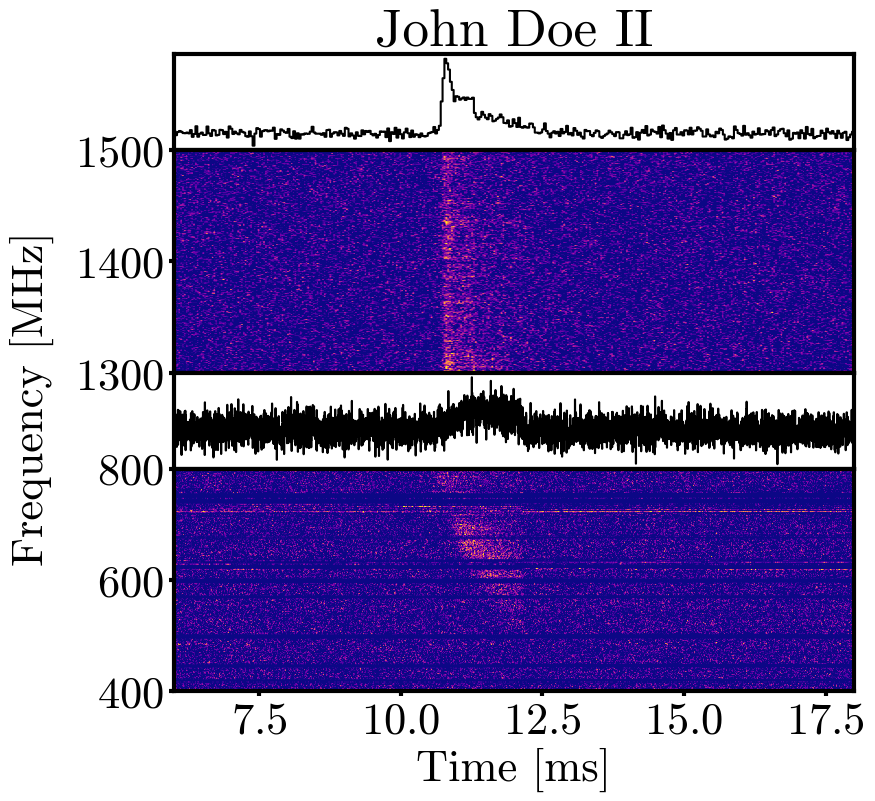

In [18]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 1*dsa_std,
             vmax=dsa_mean + 1*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 1*chime_std,
             vmax=chime_mean + 1*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('John Doe II')
plt.xlim(6, 18)
plt.show()

fig.savefig('DSA_CHIME_JohnDoeII_wfall.pdf', bbox_inches = 'tight')

In [19]:
oran_dsa = np.load('DSA_bursts/I_220506aabd_oran.npy')
dsa_burst = oran_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
oran_chime = np.load('CHIME_bursts/I_224263996_oran.npy')
chime_burst = oran_chime
chime_burst = np.roll(chime_burst[:, 20050:40600], -4000)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

FileNotFoundError: [Errno 2] No such file or directory: 'DSA_bursts/I_220506aabd_oran.npy'

No handles with labels found to put in legend.


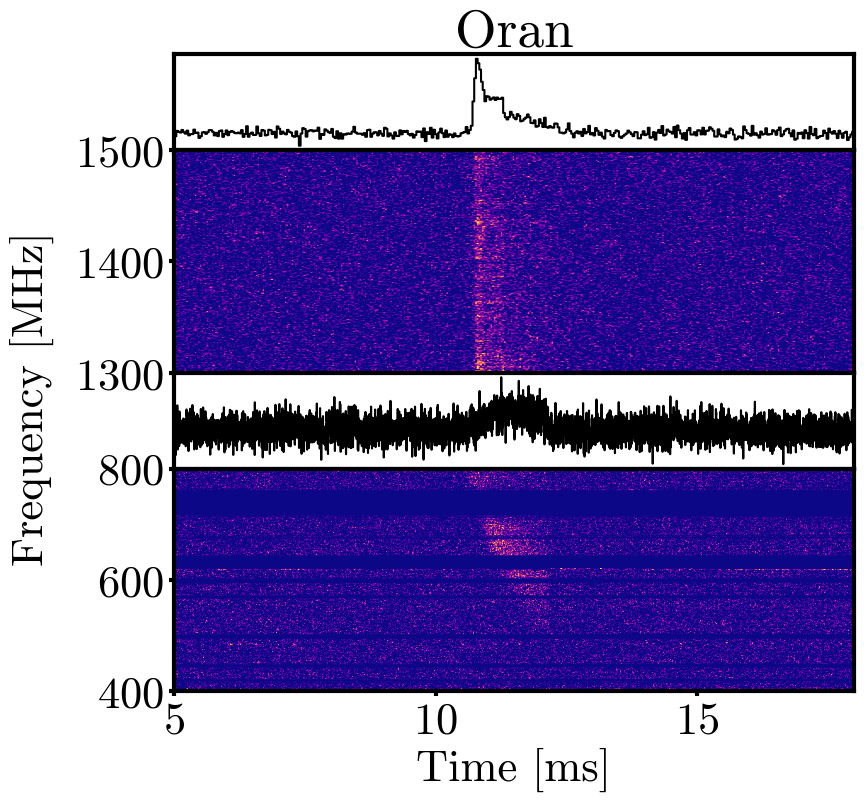

In [20]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 1*dsa_std,
             vmax=dsa_mean + 1*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

chime_burst[100:220, :] = 0
chime_burst[400:450, :] = 0
ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 1*chime_std,
             vmax=chime_mean + 1*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Oran')
plt.xlim(5, 18)
plt.show()

fig.savefig('DSA_CHIME_Oran_wfall.pdf', bbox_inches = 'tight')

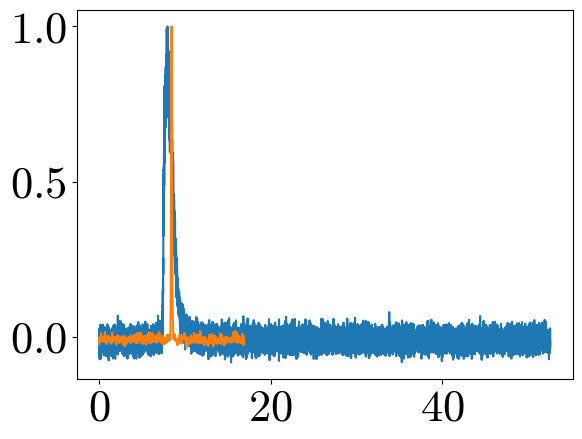

In [22]:
casey_dsa = np.load('dsa_npy/I_240229aaad_casey.npy')
dsa_burst = casey_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
casey_chime = np.load('chime_npy/I_362593221_casey.npy')
chime_burst = casey_chime
chime_burst = np.roll(chime_burst[:, 20050:40600], -4800)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No handles with labels found to put in legend.


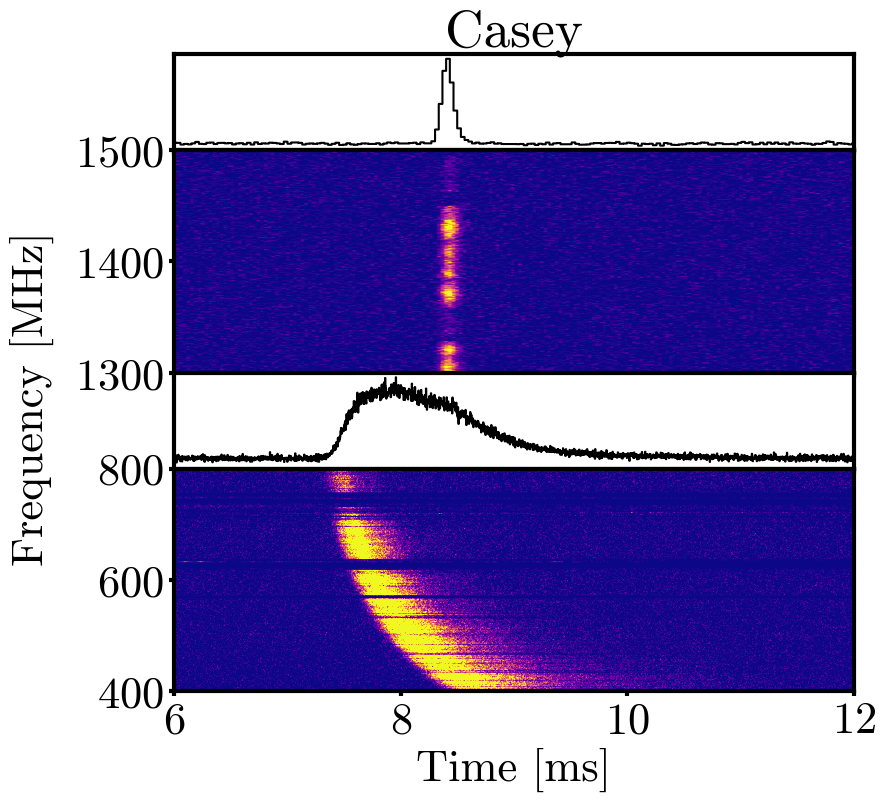

In [23]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Casey')
plt.xlim(6, 12)
plt.show()

fig.savefig('DSA_CHIME_Casey_wfall.pdf', bbox_inches = 'tight')

In [24]:
hamilton_dsa = np.load('DSA_bursts/I_230913aaao_hamilton.npy')
dsa_burst = hamilton_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
hamilton_chime = np.load('CHIME_bursts/I_318353610_hamilton.npy')
chime_burst = hamilton_chime
chime_burst = np.roll(chime_burst[:, 20050:30600], -3400)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

FileNotFoundError: [Errno 2] No such file or directory: 'DSA_bursts/I_230913aaao_hamilton.npy'

No handles with labels found to put in legend.


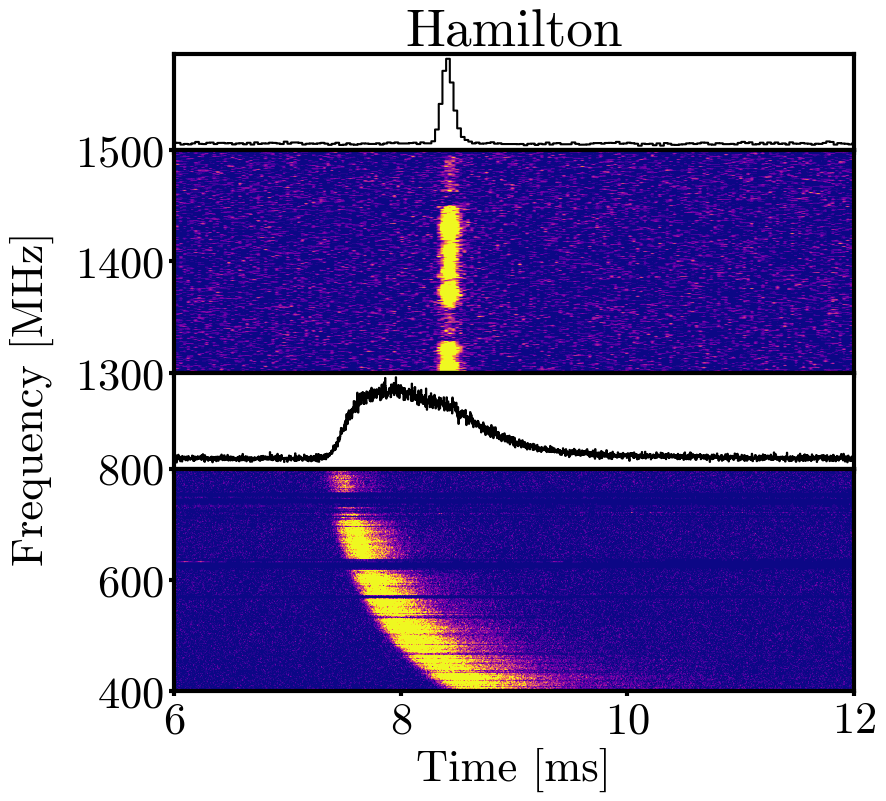

In [25]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 1*dsa_std,
             vmax=dsa_mean + 1*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

#chime_burst[100:220, :] = 0
#chime_burst[400:450, :] = 0
ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Hamilton')
plt.xlim(6, 12)
plt.show()

fig.savefig('DSA_CHIME_Hamilton_wfall.pdf', bbox_inches = 'tight')

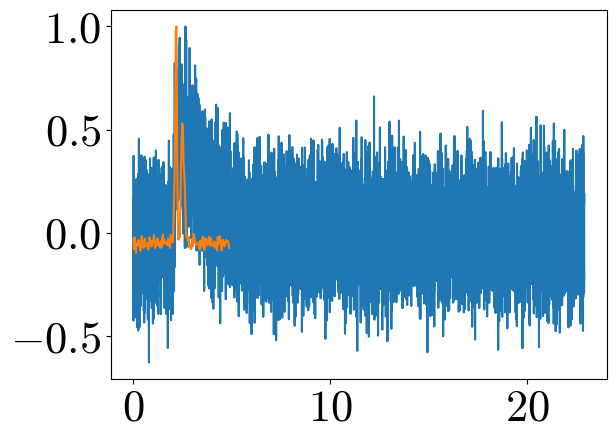

In [165]:
whitney_dsa = np.load('DSA_bursts/I_220310aaam_whitney.npy')
dsa_burst = whitney_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
whitney_chime = np.load('CHIME_bursts/I_215063905_whitney.npy')
chime_burst = whitney_chime
chime_burst = np.roll(chime_burst[:, 20650:29600], -5110)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


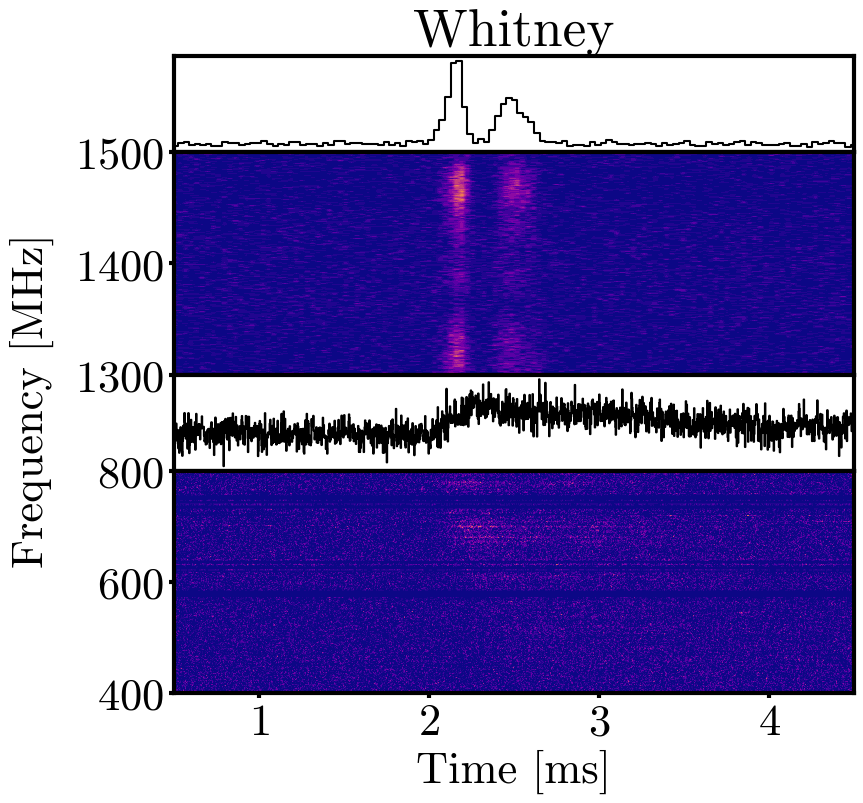

In [166]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

#chime_burst[100:220, :] = 0
#chime_burst[400:450, :] = 0
ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Whitney')
plt.xlim(0.5, 4.5)
plt.show()

fig.savefig('DSA_CHIME_Whitney_wfall.pdf', bbox_inches = 'tight')

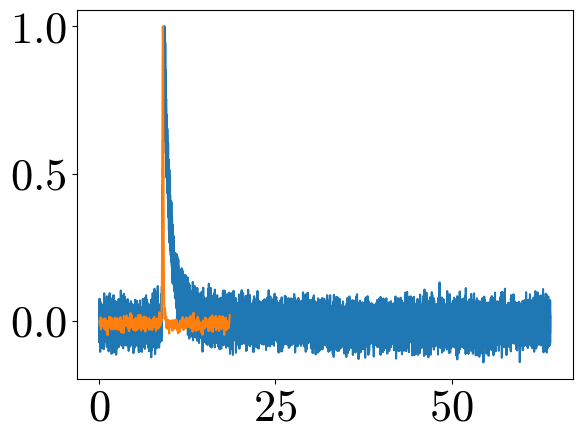

In [167]:
freya_dsa = np.load('DSA_bursts/I_230325aaag_freya.npy')
dsa_burst = freya_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
freya_chime = np.load('CHIME_bursts/I_278720455_freya.npy')
chime_burst = freya_chime
chime_burst = np.roll(chime_burst[:,15000:40000], -12700)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


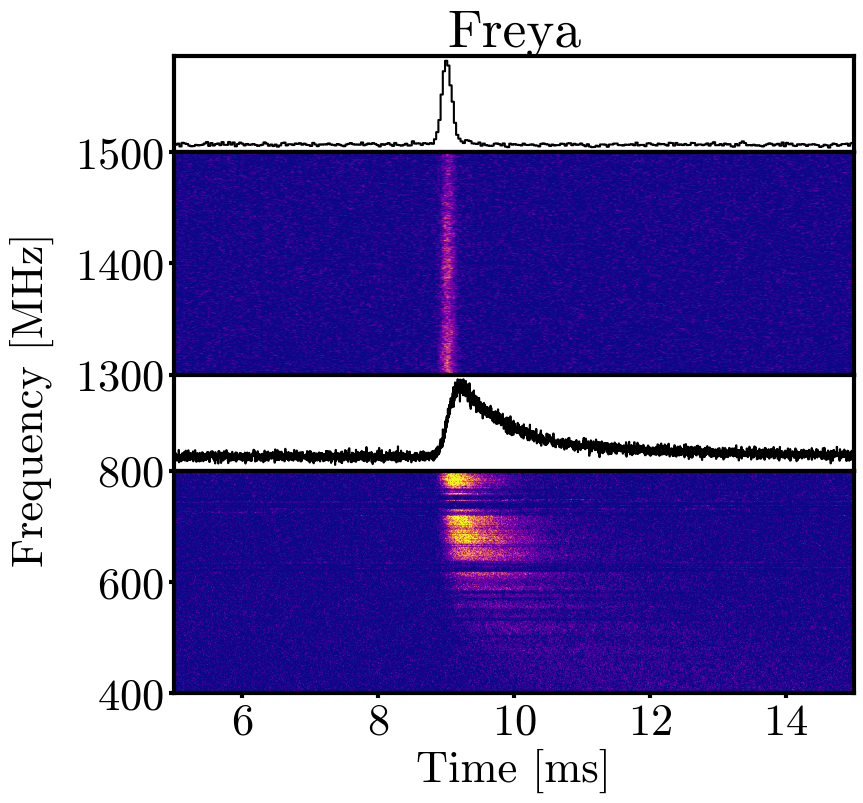

In [168]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

#chime_burst[100:220, :] = 0
#chime_burst[400:450, :] = 0
ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 3*chime_std,
             vmax=chime_mean + 3*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Freya')
plt.xlim(5, 15)
plt.show()

fig.savefig('DSA_CHIME_Freya_wfall.pdf', bbox_inches = 'tight')

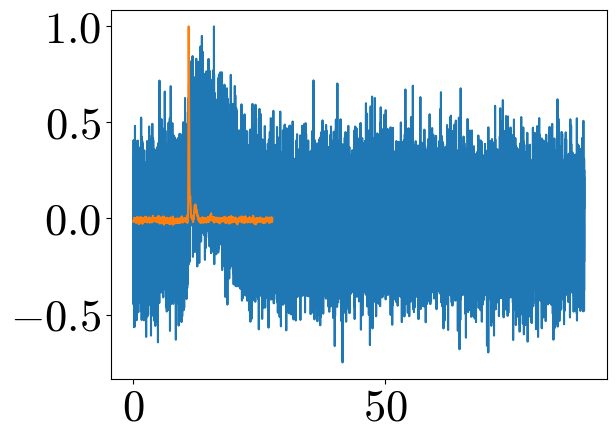

In [169]:
phineas_dsa = np.load('DSA_bursts/I_230307aaao_phineas.npy')
dsa_burst = phineas_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
phineas_chime = np.load('CHIME_bursts/I_274819243_phineas.npy')
chime_burst = phineas_chime
chime_burst = np.roll(chime_burst[:,15000:50000],-9300)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


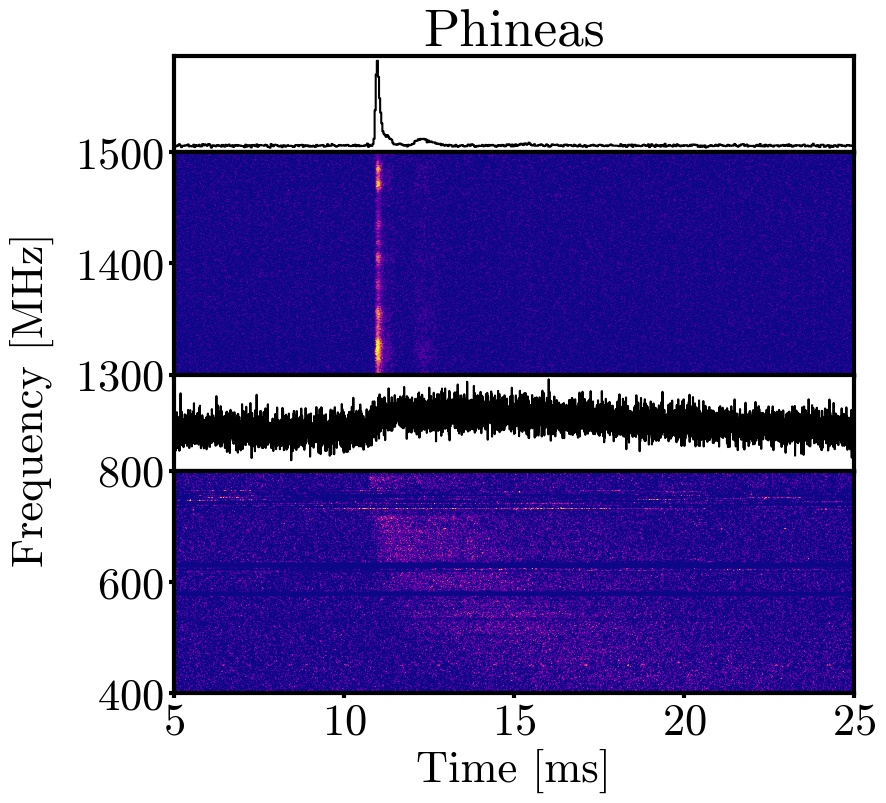

In [170]:
# Normalize data and map to range of colormap
from matplotlib.colors import ListedColormap
turbo_modified = ListedColormap(plt.get_cmap('plasma')(np.linspace(-1, 1, 32)))

fig, ax = plt.subplots(4,1, figsize=(8,7), sharex=True, gridspec_kw={"height_ratios": [3, 7, 3, 7]})

plt.subplots_adjust(
    left=0.14, bottom=0.08, right=0.99, top=0.99, wspace=0, hspace=0
)

ax[0].xaxis.set_tick_params(width=3)
ax[0].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[0].spines[axis].set_linewidth(3)  # change width
    
    
ax[0].step(dsa_time, dsa_timeseries, c = 'k')
#ax[0].text(1, 0.9, 'DSA-110')
ax[0].set_yticks([])
#ax[0].text(6.7, 0.82, '$\\Delta \\nu_{\mathrm{data}} = $' + '0.28(2) MHz', fontsize = 20)
#ax[0].set_ylabel('Flux')

ax[1].xaxis.set_tick_params(width=3)
ax[1].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[1].spines[axis].set_linewidth(3)  # change width
    
dsa_extent = [0, dsa_time[-1], 1300, 1500]

dsa_mean = np.nanmean(dsa_burst)
dsa_std = np.nanstd(dsa_burst)

ax[1].imshow(dsa_burst, 
             aspect='auto', 
             origin='upper', 
             extent=dsa_extent, 
             cmap = turbo_modified,
             vmin=dsa_mean - 3*dsa_std,
             vmax=dsa_mean + 3*dsa_std)

ax[1].set_xlabel([])
#ax[1].set_xlim(7.5, 17)
#ax[1].text(7.7, 1450, 'DSA-110', color = 'white')
#ax[1].set_ylabel('Frequency [MHz]')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

ax[2].xaxis.set_tick_params(width=3)
ax[2].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[2].spines[axis].set_linewidth(3)  # change width
    
ax[2].step(chime_time, chime_timeseries, c = 'k')
#ax[2].step(chime_time, exp_gauss(chime_event_time, *params), c = 'magenta', label = '$\\tau_{s}$ = ' + f'{round(params[3], 2)}(1) ms')
ax[2].set_yticks([])
#ax[2].set_ylabel('Flux')
ax[2].legend(frameon=False, facecolor=None, loc = 'upper right', fontsize = 20)

chime_extent = [0, chime_time[-1], 400, 800]

chime_mean = np.nanmean(chime_burst)
chime_std = np.nanstd(chime_burst)


ax[3].xaxis.set_tick_params(width=3)
ax[3].yaxis.set_tick_params(width=3)
for axis in ['top', 'bottom', 'left', 'right']:
    ax[3].spines[axis].set_linewidth(3)  # change width

#chime_burst[100:220, :] = 0
#chime_burst[400:450, :] = 0
ax[3].imshow(chime_burst, 
             aspect='auto', 
             origin='upper', 
             extent=chime_extent, 
             cmap = turbo_modified,
             vmin=chime_mean - 1*chime_std,
             vmax=chime_mean + 1*chime_std)

#ax[3].text(6, 700, 'CHIME/FRB', color = 'white')
ax[3].set_xlabel('Time [ms]')
#ax[3].set_xlim(7.5, 17)
#ax[3].set_xticks(np.linspace(2800, 8000, 4), np.linspace(0, 10, 4))
#ax[3].set_ylabel('Frequency [MHz]')
#ax[4].set_ylim([400,800])
fig.text(-0.065, 0.5, 'Frequency [MHz]', va='center', rotation='vertical')

#freqs = np.array(constants.FPGA_FREQ)[:]
#ax[1].hlines(freqs[chan_mask], extent[0], extent[0]+(abs(extent[0])/10), \
#                 color='red', lw=1, alpha=1, zorder=1)

#ax[1].xaxis.set_tick_params(labelbottom=True)

fig.align_ylabels(ax[:])

#ax[1].text(0.69, 0.93, 'FRB20201230B', transform = ax[1].transAxes, color='white', fontsize = 26, fontweight='bold', bbox=props)         

ax[0].set_title('Phineas')
plt.xlim(5, 25)
plt.show()

fig.savefig('DSA_CHIME_Phineas_wfall.pdf', bbox_inches = 'tight')

In [ ]:
phineas_dsa = np.load('DSA_bursts/I_230307aaao_phineas.npy')
dsa_burst = phineas_dsa
dsa_time = np.linspace(0, dsa_burst.shape[1]*dsa_tres, dsa_burst.shape[1])
dsa_timeseries = np.nansum(dsa_burst, axis=0) / np.nanmax(np.nansum(dsa_burst, axis=0))
phineas_chime = np.load('CHIME_bursts/I_274819243_phineas.npy')
chime_burst = phineas_chime
chime_burst = np.roll(chime_burst[:,15000:50000],-9300)
chime_time = np.linspace(0, chime_burst.shape[1]*chime_tres, chime_burst.shape[1])
chime_timeseries = np.nansum(chime_burst, axis=0) / np.nanmax(np.nansum(chime_burst, axis=0))

plt.plot(chime_time, chime_timeseries)
plt.plot(dsa_time, dsa_timeseries)